<a href="https://colab.research.google.com/github/Jupiterian/ML-Learning-Portfolio/blob/main/Linear%20Algebra/SVD_Image_Compressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVD Image Compressor
The following notebook compresses and then rebuilds color images through SVD. While not used a lot in the real world, this is a clever application of Linear Algebra.
The SVD compressor compresses images of 256 by 256 and rebuilds them.

## Writeup
Images are from the [Classified images dataset (ImageNet 256×256)](https://www.kaggle.com/datasets/dimensi0n/imagenet-256) kaggle dataset. You can chose any given image and then the code will reconstruct it.

Image → RGB Matrix → SVD → U Σ Vᵀ → Rank-k Approximation → Reconstructed Image

The image is first loaded in using the ```PIL``` module. It's RGB values are then extracted by using ```list(img.getdata())```. Once the RGB values have been extracted, each of the red, green, and blue matrices are decomposed into SVD form. From here, the first $k$ singular values from ```S```, and their coresponding columns of ```U``` and rows of ```Vh``` are sliced. After slicing, by use of ```np.matmul```, a new set of compressed red, green, and blue matrices are rebuilt. This is then combined into one big tensor of size ```(256, 256, 3)```. ```PIL``` is then called again to rebuild the image.

An important note is that the rgb_image is originally of dtype ```float64``` and then must be converted to ```uint8``` in order for PIL to be able to properly rebuilt it.

## Import Modules

In [1]:
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

## Dataset Creation (for testing purposes)

In [3]:
import kagglehub
path = kagglehub.dataset_download("dimensi0n/imagenet-256")

Using Colab cache for faster access to the 'imagenet-256' dataset.


# Image Loading and Compression

### Before

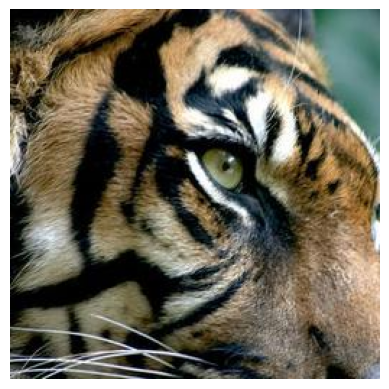

In [5]:
# load image
item = "tiger" # you can select any item here
path = f"/kaggle/input/imagenet-256/{item}"
img = Image.open(f"{path}/032.jpg") # you can select any image number here
plt.imshow(img)
plt.axis("off")
plt.show()

### Compress Image

In [6]:
# get pixels
all_pixels = list(img.getdata())
red = [pixel[0] for pixel in all_pixels]
green = [pixel[1] for pixel in all_pixels]
blue = [pixel[2] for pixel in all_pixels]
red = np.array(red)
green = np.array(green)
blue = np.array(blue)
red = red.reshape([256, 256])
blue = blue.reshape([256, 256])
green = green.reshape([256, 256])

#### Singular Values Plot

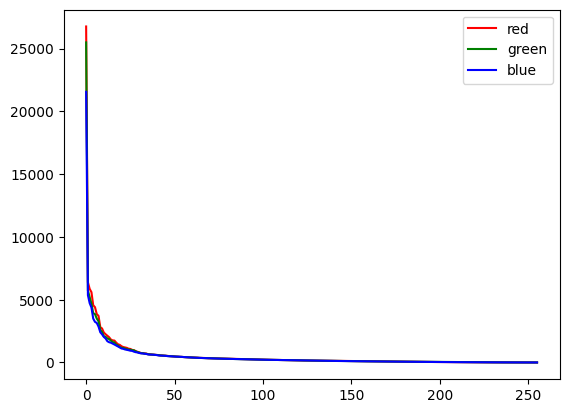

In [7]:
U1, s1, Vh1 = np.linalg.svd(red, full_matrices=True)
U2, s2, Vh2 = np.linalg.svd(green, full_matrices=True)
U3, s3, Vh3 = np.linalg.svd(blue, full_matrices=True)

s1M = np.diag(s1)
s2M = np.diag(s2)
s3M = np.diag(s3)

fig, ax = plt.subplots()
ax.plot(s1, color="red", label="red")
ax.plot(s2, color="green", label="green")
ax.plot(s3, color="blue", label="blue")
ax.legend()
plt.show()
# As you can see the singular values start to drop off in value quite drastically. If a singular value is very small, the corresponding vector hardly contributes to the overall image.

In [18]:
# Chose k and discard remaining rows and column
k = 20
# slice arrays
U1M = U1[:, :k]
U2M = U2[:, :k]
U3M = U3[:, :k]

s1MM = s1M[:k, :k]
s2MM = s2M[:k, :k]
s3MM = s3M[:k, :k]

Vh1M = Vh1[:k, :]
Vh2M = Vh2[:k, :]
Vh3M = Vh3[:k, :]

In [19]:
# Rebuild Image
redCompress = np.matmul(np.matmul(U1M, s1MM), Vh1M)
greenCompress = np.matmul(np.matmul(U2M, s2MM), Vh2M)
blueCompress = np.matmul(np.matmul(U3M, s3MM), Vh3M)

rgb_img = np.dstack((redCompress, greenCompress, blueCompress))
rgb_img = rgb_img.astype(np.uint8)
img_rebuilt = Image.fromarray(rgb_img, mode='RGB')


/tmp/ipykernel_1997/3889407653.py:8: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img_rebuilt = Image.fromarray(rgb_img, mode='RGB')


### After

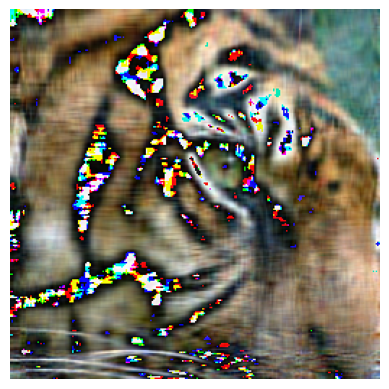

In [20]:
# Show rebuilt image
plt.imshow(img_rebuilt)
plt.axis("off")
plt.show()